In [54]:
import os
import glob
import h5py
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_35456\1914619217.py:18: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
%matplotlib notebook

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
exp_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\826032\826032_2026-01-29_12-59-37\slap2\qc\ExperimentSummary\Summary_Voltage-260212-114331.mat"

In [5]:
from vip_slap2_analysis.voltage.summary import VoltageSummary

In [6]:
v = VoltageSummary(exp_path)

In [7]:
print(f'Data processed at {v.analyze_hz()}')
print(f'Number of rois/DMD: \nDMD1 = {v.n_rois[0]} rois\nDMD2 = {v.n_rois[1]} rois')

Data processed at 1000.0
Number of rois/DMD: 
DMD1 = 10 rois
DMD2 = 11 rois


In [32]:
import numpy as np

def concat_rois_across_trials(vs, dmd: int = 1, drop_discarded: bool = True, dtype=np.float32):
    """
    Concatenate ROI traces across all valid trials for a given DMD.

    Assumes vs.get_roi_traces(dmd, trial) returns shape (n_samples, n_rois)
    i.e. samples first, ROI second (as your screenshot shows).

    Returns
    -------
    roi_traces : list[np.ndarray]
        List length n_rois. Each element is a 1D array of concatenated samples.
    trial_slices : list[tuple[int, slice]]
        (trial_index_1based, slice_into_concatenated_time) for bookkeeping.
    """
    dmd0 = dmd - 1
    valid_trials = vs.valid_trials[dmd0]  # should be 1-indexed
    n_rois = vs.n_rois[dmd0]

    chunks_by_roi = [[] for _ in range(n_rois)]
    trial_slices = []
    t_cursor = 0

    for trial in valid_trials:
        X = vs.get_roi_traces(dmd=dmd, trial=trial, drop_discarded=False, dtype=dtype)
        # X: (n_samples, n_rois)

        if drop_discarded:
            df = vs.get_discard_frames(dmd=dmd, trial=trial)
            df = np.asarray(df).astype(bool).squeeze()
            if df.ndim != 1:
                df = df.reshape(-1)

            # Align just in case of minor shape weirdness
            if df.size != X.shape[0]:
                df = df[:X.shape[0]] if df.size > X.shape[0] else np.pad(df, (0, X.shape[0] - df.size), constant_values=False)

            X = X[~df, :]  # keep non-discarded samples

        seg_len = X.shape[1]
        trial_slices.append((trial, slice(t_cursor, t_cursor + seg_len)))
        t_cursor += seg_len

        # Append per ROI (column)
        for r in range(n_rois):
            chunks_by_roi[r].append(X[r,:])

    roi_traces = [
        np.concatenate(chunks, axis=0) if chunks else np.array([], dtype=dtype)
        for chunks in chunks_by_roi
    ]

    return roi_traces, trial_slices

In [33]:
roi_traces, trial_slices = concat_rois_across_trials(v, dmd=1, drop_discarded=False)
print(len(roi_traces), roi_traces[0].shape)

10 (95728,)


In [41]:
sample_rate = v.analyze_hz()
n_samples = len(roi_traces[0])
dur = n_samples/sample_rate
x = np.linspace(0,dur,n_samples)

<IPython.core.display.Javascript object>


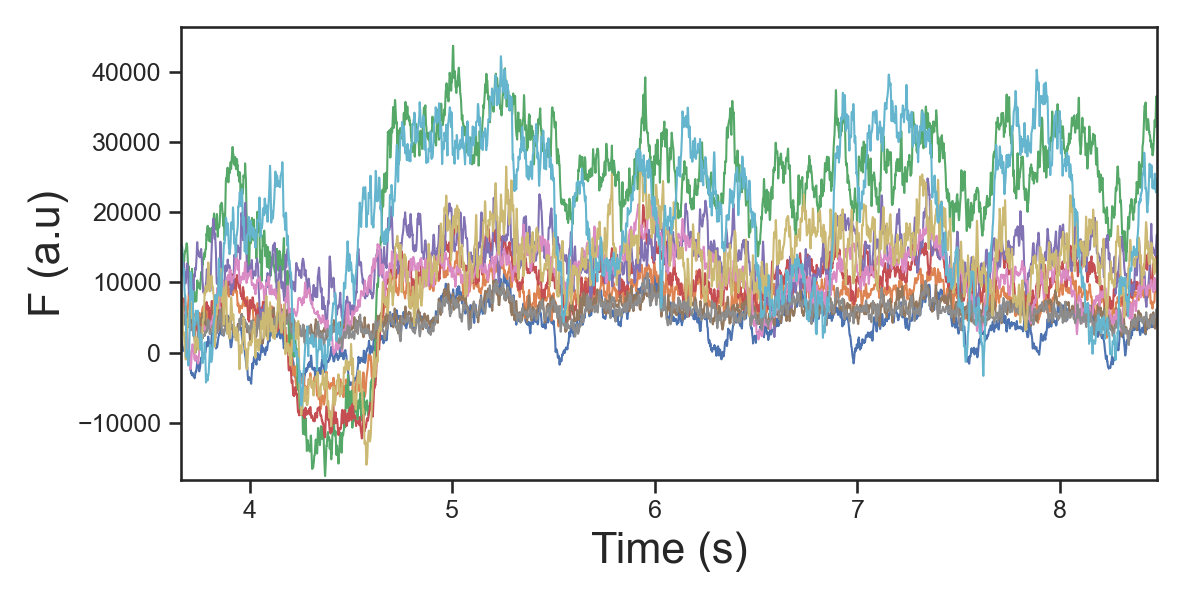

In [72]:
fig,ax=plt.subplots(figsize=(8,4))

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

for roi in roi_traces:
    ax.plot(x,roi-np.mean(roi),lw=1)
ax.set_ylabel('F (a.u)')
ax.set_xlabel('Time (s)')

fig.tight_layout()

In [24]:
v.get_roi_traces(dmd=1,trial=1,drop_discarded=False).shape

(10, 23932)

In [19]:
v.valid_trials[0]

[1, 2, 3, 4]